[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emmaruyiyang/MMAI-MemeSonic/blob/main/image-text-fusion/incongruity_aware_fusion.ipynb)

# Sentiment-Incongruity-Aware Fusion for Meme Understanding

This notebook implements a **Sentiment-Incongruity-Aware Fusion** method on the MET-Meme dataset.
It can run standalone, independently of the main HW2 notebook.

### Motivation
Standard fusion methods (Concat, LMF, etc.) measure incongruity in raw **embedding space** —
capturing geometric distance between encoder outputs, not meaningful semantic tension.
Meme meaning, however, arises from the contradiction between **image sentiment** and **text sentiment**:
a cheerful image paired with a sarcastic caption. This method explicitly models that disagreement.

### Design
Each encoder output is projected into a 5-class **sentiment probability space**. The fusion computes:
- `align`: `(img_emb + txt_emb) / 2` — shared content signal
- `sentiment_incong`: `|img_sentiment - txt_sentiment|` — per-class emotional disagreement
- `incong_gate`: a learned scalar (per sample) controlling how much incongruity matters

Final representation: `[align(64) | gate * sentiment_incong(5)]` → MLP head

In [ ]:
# Install dependencies (run once; skip if already installed)
!pip install -q torch==2.3.1 torchvision==0.18.1
!pip install -q transformers==4.40.0 datasets

import sys

!git clone https://github.com/pliang279/MultiBench.git

# MultiBench is located one level up from this notebook.
# MultiBench/datasets/ shadows the HuggingFace 'datasets' package,
# so we import HuggingFace datasets first, then add MultiBench to sys.path.
_mb = [p for p in sys.path if 'MultiBench' in p]
for p in _mb:
    sys.path.remove(p)

from datasets import load_dataset  # now safely resolves to HuggingFace

sys.path.insert(0, '../MultiBench')  # MultiBench is at hw2/MultiBench/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer, BertModel
from unimodals.common_models import MLP
from training_structures.Supervised_Learning import train, test, MMDL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 5
print(f'Using device: {device}')

Using device: cuda


## 1. Dataset
Load the MET-Meme dataset from HuggingFace and extract BERT [CLS] embeddings for text.
Embeddings are cached to disk so they are only computed once.

In [ ]:
hf = load_dataset('Emmaruyi/met-meme-filtered')

# ResNet-50 expects 224x224 and ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class CachedDataset(Dataset):
    def __init__(self, hf_split, text_embeddings=None):
        self.data = hf_split
        self.text_embeddings = text_embeddings

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = transform(row['image'].convert('RGB'))
        text  = self.text_embeddings[idx] if self.text_embeddings is not None else row['caption']
        label = row['intention_num'] - 1
        return image, text, label

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2711 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/338 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/340 [00:00<?, ? examples/s]

In [ ]:
def extract_text_embeddings(captions, device='cpu'):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    bert = BertModel.from_pretrained('bert-base-uncased').to(device)
    bert.eval()
    embeddings = []
    with torch.no_grad():
        for caption in tqdm(captions, desc='Extracting BERT embeddings'):
            inputs = tokenizer(caption, return_tensors='pt', truncation=True,
                               max_length=128, padding='max_length').to(device)
            outputs = bert(**inputs)
            embeddings.append(outputs.last_hidden_state[:, 0, :].squeeze(0).cpu())
    return torch.stack(embeddings)


EMB_CACHE = 'all_text_emb.pt'

if os.path.exists(EMB_CACHE):
    print('Loading cached BERT embeddings...')
    all_text_emb = torch.load(EMB_CACHE)
else:
    print('Extracting BERT embeddings (this takes a few minutes)...')
    all_text_emb = {
        'train':      extract_text_embeddings(hf['train']['caption'],      device),
        'validation': extract_text_embeddings(hf['validation']['caption'], device),
        'test':       extract_text_embeddings(hf['test']['caption'],       device),
    }
    torch.save(all_text_emb, EMB_CACHE)
    print(f'Saved to {EMB_CACHE}')

trainset = CachedDataset(hf['train'],      all_text_emb['train'])
valset   = CachedDataset(hf['validation'], all_text_emb['validation'])
testset  = CachedDataset(hf['test'],       all_text_emb['test'])

traindata = DataLoader(trainset, batch_size=64, shuffle=True)
validdata = DataLoader(valset,   batch_size=64)
testdata  = DataLoader(testset,  batch_size=64)

print(f'Train: {len(trainset)}, Val: {len(valset)}, Test: {len(testset)}')


Loading cached BERT embeddings...
Train: 2711, Val: 338, Test: 340


## 2. Encoders

- **ImageEncoder**: ResNet-50 pretrained on ImageNet, backbone frozen, only the final projection layer is trained.
- **TextEncoder**: BERT `bert-base-uncased`, backbone frozen, only a linear projection is trained. The 768-dim `[CLS]` embeddings are already cached from the dataset step.

In [ ]:
import torchvision.models as tv_models

class ImageEncoder(nn.Module):
    """ResNet-50 pretrained on ImageNet, backbone frozen, projection trainable."""
    def __init__(self, output_dim=64):
        super().__init__()
        resnet = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the final classification head; keep everything up to avgpool
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # -> (batch, 2048, 1, 1)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(2048, output_dim)

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x).flatten(1)  # (batch, 2048)
        return self.proj(feat)                  # (batch, output_dim)


class TextEncoder(nn.Module):
    """BERT bert-base-uncased, backbone frozen. Input: cached 768-dim [CLS] embeddings."""
    def __init__(self, input_dim=768, output_dim=64):
        super().__init__()
        # Backbone is already applied offline (BERT embeddings are pre-cached).
        # This layer just projects the cached 768-dim vector.
        self.proj = nn.Linear(input_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.proj(x))          # (batch, output_dim)

## 3. Sentiment-Incongruity-Aware Fusion

Unlike embedding-space incongruity (e.g. `|img_emb - txt_emb|` which mixes unrelated feature dimensions),
this fusion first maps each modality to a **sentiment probability distribution** and then computes disagreement there.

The intuition: if the image looks positive but the text reads negative, the `sentiment_incong` vector will have
large values at those conflicting classes — a direct signal of the meme's ironic tension.

In [ ]:
class SentimentIncongruityFusion(nn.Module):
    """
    Projects each modality into sentiment probability space,
    then computes emotional disagreement as the incongruity signal.
    Output dim: input_dim + num_sentiments = 64 + 5 = 69
    """
    def __init__(self, input_dim=64, num_sentiments=5):
        super().__init__()
        self.img_sentiment = nn.Linear(input_dim, num_sentiments)
        self.txt_sentiment = nn.Linear(input_dim, num_sentiments)
        # Gate: learn how much incongruity matters per sample
        self.incong_gate = nn.Sequential(
            nn.Linear(input_dim * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        img, txt = x[0], x[1]  # (batch, 64) each

        img_sent = F.softmax(self.img_sentiment(img), dim=-1)  # (batch, 5)
        txt_sent = F.softmax(self.txt_sentiment(txt), dim=-1)  # (batch, 5)

        # Emotional disagreement: where do the two modalities disagree?
        sentiment_incong = torch.abs(img_sent - txt_sent)          # (batch, 5)

        gate  = self.incong_gate(torch.cat([img, txt], dim=-1))    # (batch, 1)
        align = (img + txt) / 2                                     # (batch, 64)

        return torch.cat([align, gate * sentiment_incong], dim=-1) # (batch, 69)


## 4. Unimodal Baselines

Train image-only and text-only models using the same pretrained encoders, for direct comparison with the fusion model.

In [ ]:
def train_unimodal(model, modality_idx, name, epochs=10, lr=5e-4):
    """Train a unimodal model, return best test accuracy."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for batch in traindata:
            x = batch[modality_idx].float().to(device)
            y = batch[2].long().to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in validdata:
                x = batch[modality_idx].float().to(device)
                y = batch[2].long().to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total   += y.size(0)
        val_acc = correct / total
        print(f'  [{name}] Epoch {epoch+1:02d} — val acc: {val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in testdata:
            x = batch[modality_idx].float().to(device)
            y = batch[2].long().to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    test_acc = 100 * correct / total
    print(f'  [{name}] Test Accuracy: {test_acc:.2f}%')
    return test_acc


# Image-only: ResNet-50 frozen backbone + projection + linear head
image_unimodal = nn.Sequential(
    ImageEncoder(output_dim=64),
    nn.Linear(64, num_classes)
)

# Text-only: BERT cached embedding + projection + linear head
text_unimodal = nn.Sequential(
    TextEncoder(output_dim=64),
    nn.Linear(64, num_classes)
)

unimodal_results = {}

print('='*45)
print('Training Unimodal-Image (ResNet-50 frozen)...')
print('='*45)
unimodal_results['Unimodal-Image'] = train_unimodal(image_unimodal, modality_idx=0, name='Image')

print()
print('='*45)
print('Training Unimodal-Text (BERT cached)...')
print('='*45)
unimodal_results['Unimodal-Text'] = train_unimodal(text_unimodal, modality_idx=1, name='Text')

## 4. Training

In [ ]:
incong_fusion   = SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes)
incong_head     = MLP(69, 256, num_classes)  # 64 align + 5 sentiment incongruity
incong_encoders = [ImageEncoder(output_dim=64), TextEncoder(output_dim=64)]

print('Training Sentiment-Incongruity-Aware Fusion...')
train(
    incong_encoders, incong_fusion, incong_head,
    traindata, validdata,
    total_epochs=10,
    task='classification',
    optimtype=torch.optim.AdamW,
    is_packed=False,
    lr=5e-4,
    save='incong_fusion.pt',
    weight_decay=1e-3,
    objective=torch.nn.CrossEntropyLoss(),
    input_to_float=False
)

incong_model = torch.load('incong_fusion.pt').to(device)
print('\n--- Test Results ---')
test(
    incong_model, testdata,
    is_packed=False,
    task='classification',
    criterion=torch.nn.CrossEntropyLoss(),
    no_robust=True
)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 42.3MB/s]


Training Sentiment-Incongruity-Aware Fusion...
Epoch 0 train loss: tensor(1.2511, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(1.2730, device='cuda:0') acc: 0.46745562130177515
Saving Best
Epoch 1 train loss: tensor(1.1675, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(1.2585, device='cuda:0') acc: 0.3875739644970414
Epoch 2 train loss: tensor(1.1141, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(1.3198, device='cuda:0') acc: 0.32840236686390534
Epoch 3 train loss: tensor(1.0785, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(1.3524, device='cuda:0') acc: 0.32840236686390534
Epoch 4 train loss: tensor(1.0460, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(1.3922, device='cuda:0') acc: 0.3254437869822485
Epoch 5 train loss: tensor(1.0525, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 5 valid loss: tensor(1.3621, device='cuda:0') acc: 0.31952662721893493
Epoch 6 train loss: tenso

## 5. Evaluation & Visualization

For each of 4 test samples, plot:
- **Image sentiment distribution** — what the image encoder "thinks" emotionally
- **Text sentiment distribution** — what the text encoder "thinks" emotionally
- **Incongruity** — the absolute difference: high bars = strong emotional conflict at that class

In [ ]:
# ── Test accuracy ─────────────────────────────────────────────────────────────
incong_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, text, label in testdata:
        imgs  = imgs.float().to(device)
        text  = text.float().to(device)
        label = label.long().to(device)
        out   = incong_model([imgs, text])
        correct += (out.argmax(1) == label).sum().item()
        total   += label.size(0)
print(f'Test Accuracy: {100 * correct / total:.2f}%')

# ── Parameter count ───────────────────────────────────────────────────────────
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

incong_full = MMDL(
    [ImageEncoder(output_dim=64), TextEncoder(output_dim=64)],
    SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes),
    MLP(69, 256, num_classes)
)
print(f'Total trainable parameters: {count_params(incong_full):,}')


Test Accuracy: 43.53%
Total trainable parameters: 200,336


In [ ]:
# ── Summary comparison ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

all_results = {
    **unimodal_results,
    'IncongruityFusion': 100 * correct / total,  # from eval_acc cell above
}

names = list(all_results.keys())
accs  = [all_results[n] for n in names]
colors = ['steelblue', 'darkorange', 'crimson']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Unimodal vs Sentiment-Incongruity-Aware Fusion\n(pretrained encoders, frozen backbone)')
ax.set_ylim(0, max(accs) + 8)
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (5-class)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('unimodal_vs_fusion.png', dpi=150)
plt.show()
print('Saved: unimodal_vs_fusion.png')

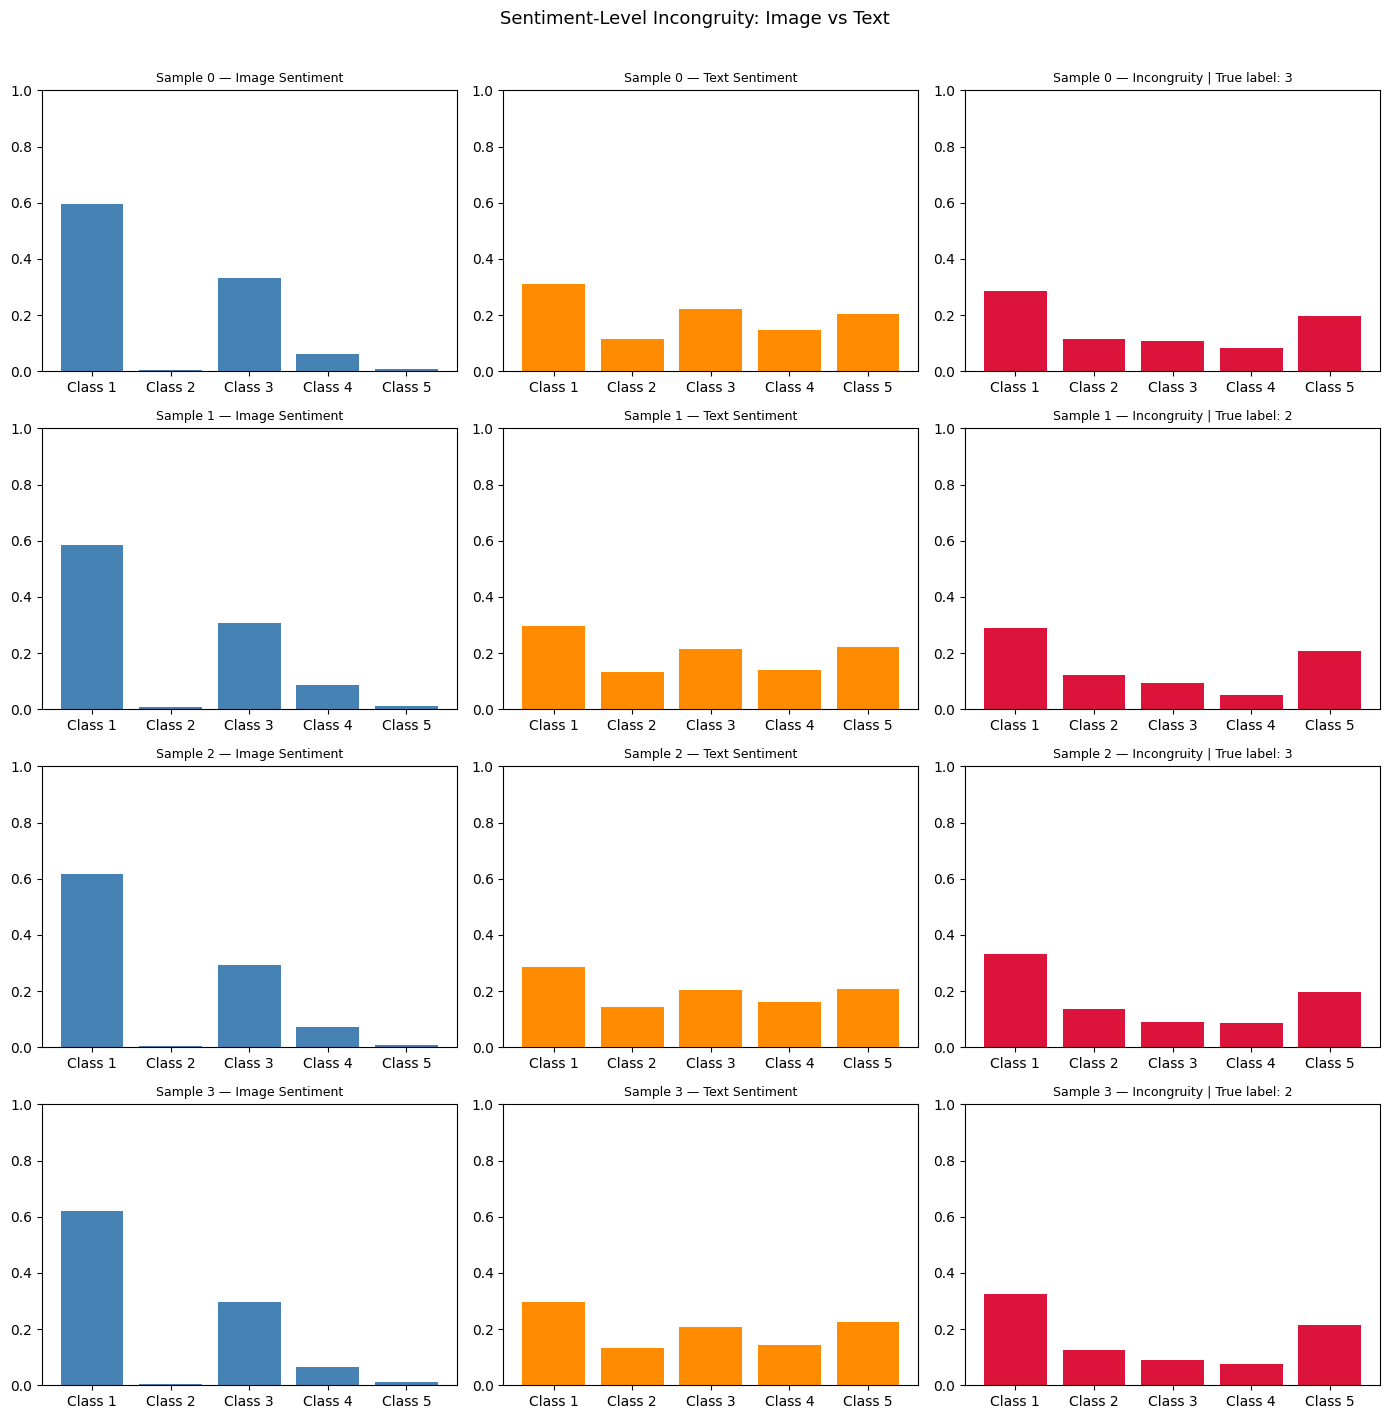

Saved: incongruity_sentiment_vis.png


In [ ]:
# ── Visualize sentiment distributions for 4 test samples ─────────────────────
incong_model.eval()
imgs, text, labels = next(iter(testdata))
imgs = imgs.float().to(device)
text = text.float().to(device)

enc_img  = incong_model.encoders[0].to(device)
enc_txt  = incong_model.encoders[1].to(device)
fuse_mod = incong_model.fuse.to(device)

with torch.no_grad():
    img_emb  = enc_img(imgs)
    txt_emb  = enc_txt(text)
    img_sent = F.softmax(fuse_mod.img_sentiment(img_emb), dim=-1).cpu().numpy()
    txt_sent = F.softmax(fuse_mod.txt_sentiment(txt_emb), dim=-1).cpu().numpy()
    incong   = abs(img_sent - txt_sent)

label_names = [f'Class {i+1}' for i in range(num_classes)]
fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for i in range(4):
    axes[i, 0].bar(label_names, img_sent[i], color='steelblue')
    axes[i, 0].set_title(f'Sample {i} — Image Sentiment', fontsize=9)
    axes[i, 0].set_ylim(0, 1)

    axes[i, 1].bar(label_names, txt_sent[i], color='darkorange')
    axes[i, 1].set_title(f'Sample {i} — Text Sentiment', fontsize=9)
    axes[i, 1].set_ylim(0, 1)

    axes[i, 2].bar(label_names, incong[i], color='crimson')
    axes[i, 2].set_title(
        f'Sample {i} — Incongruity | True label: {labels[i].item()+1}', fontsize=9
    )
    axes[i, 2].set_ylim(0, 1)

plt.suptitle('Sentiment-Level Incongruity: Image vs Text', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('incongruity_sentiment_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: incongruity_sentiment_vis.png')


## 6. CLIP Embedding Space Visualization

We use CLIP (ViT-B/32) to embed image-text pairs into a **shared semantic space** — unlike BERT+ResNet which live in separate spaces, CLIP image and text embeddings are directly comparable via cosine similarity.

For 10 meme samples we visualize:
1. **Similarity matrix** — cosine similarity between all image-text pairs; diagonal = correct matches
2. **t-SNE** — image embeddings (squares) and text embeddings (circles) colored by sample index; good alignment = same-color pairs cluster together

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git

/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_29913/1822593474.py:35: RuntimeWarning: divide by zero encountered in matmul
  sim_matrix = img_emb @ txt_emb.T   # (10, 10)  row=image, col=text
/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_29913/1822593474.py:35: RuntimeWarning: overflow encountered in matmul
  sim_matrix = img_emb @ txt_emb.T   # (10, 10)  row=image, col=text
/var/folders/dl/qk95d0zj23j9sjmtb6_4gh_w0000gn/T/ipykernel_29913/1822593474.py:35: RuntimeWarning: invalid value encountered in matmul
  sim_matrix = img_emb @ txt_emb.T   # (10, 10)  row=image, col=text


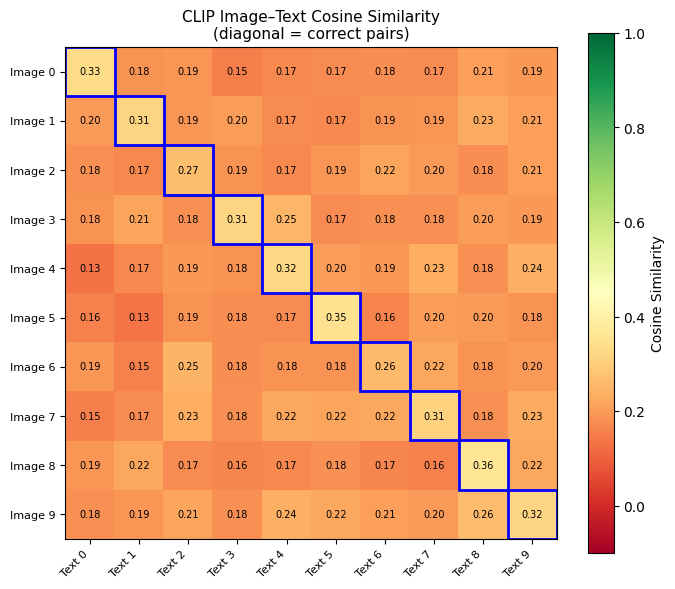

Mean diagonal (correct pairs) : 0.3150
Mean off-diagonal (wrong pairs): 0.1911
Alignment gap                  : 0.1240


In [20]:
import clip
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from PIL import Image as PILImage

# ── Load CLIP ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()

# ── Sample 10 memes from test set ─────────────────────────────────────────────
N = 10
indices = list(range(N))  # change to random indices if preferred
samples = [hf['test'][i] for i in indices]

images   = [clip_preprocess(s['image'].convert('RGB')) for s in samples]
captions = [s['caption'] for s in samples]
labels   = [s['intention_num'] - 1 for s in samples]

image_input = torch.stack(images).to(device)                        # (10, 3, 224, 224)
text_input  = clip.tokenize(captions, truncate=True).to(device)     # (10, 77)

# ── Extract CLIP embeddings ───────────────────────────────────────────────────
with torch.no_grad():
    img_emb  = clip_model.encode_image(image_input)   # (10, 512)
    txt_emb  = clip_model.encode_text(text_input)     # (10, 512)

img_emb = torch.nn.functional.normalize(img_emb, dim=-1).cpu().numpy()
txt_emb = torch.nn.functional.normalize(txt_emb, dim=-1).cpu().numpy()

# ── 1. Cosine similarity matrix ───────────────────────────────────────────────
sim_matrix = img_emb @ txt_emb.T   # (10, 10)  row=image, col=text

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.1, vmax=1.0)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels([f'Text {i}' for i in range(N)], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f'Image {i}' for i in range(N)], fontsize=8)
ax.set_title('CLIP Image–Text Cosine Similarity\n(diagonal = correct pairs)', fontsize=11)

# Annotate each cell with the value
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(sim_matrix[i, j]) < 0.7 else 'white')

# Highlight diagonal
for i in range(N):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor='blue', linewidth=2))

plt.tight_layout()
plt.savefig('clip_similarity_matrix.png', dpi=150)
plt.show()

diag_mean = np.diag(sim_matrix).mean()
offdiag   = sim_matrix[~np.eye(N, dtype=bool)].mean()
print(f'Mean diagonal (correct pairs) : {diag_mean:.4f}')
print(f'Mean off-diagonal (wrong pairs): {offdiag:.4f}')
print(f'Alignment gap                  : {diag_mean - offdiag:.4f}')

/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/en

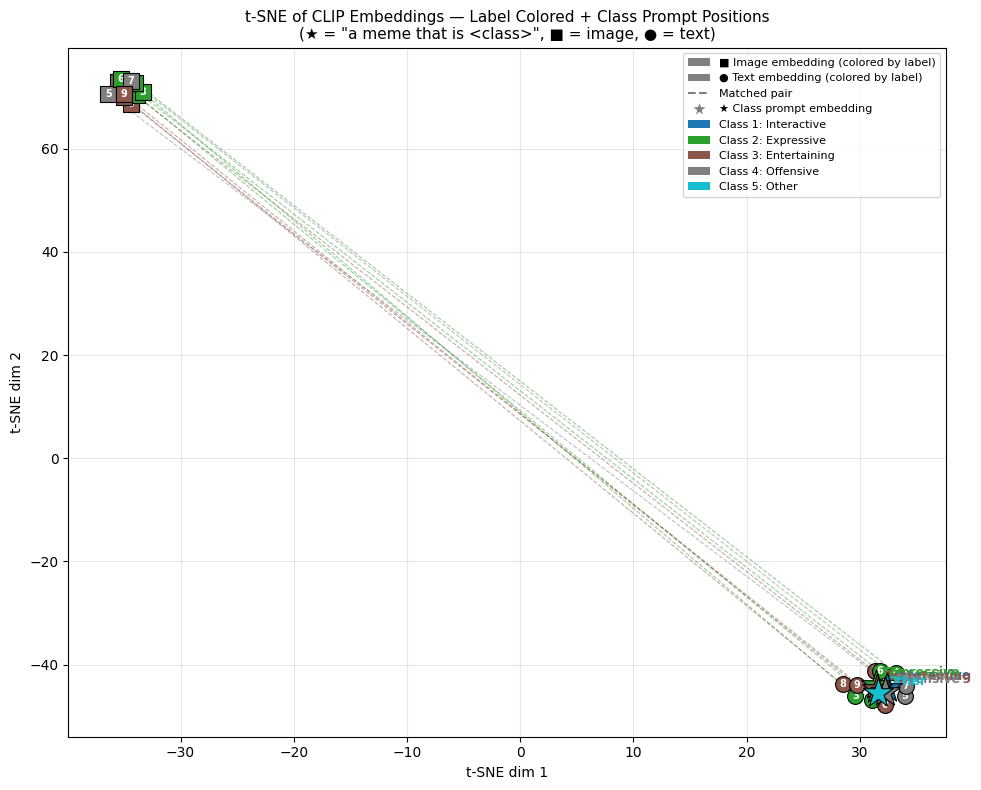

Saved: clip_tsne_enhanced.png

Nearest class prompt for each sample (cosine similarity):
Sample   True Label     Nearest Prompt    Sim
------------------------------------------------
0        Entertaining   img→Interactive 0.223
                        txt→Other      0.733
1        Expressive     img→Expressive 0.222
                        txt→Other      0.835
2        Entertaining   img→Other      0.260
                        txt→Entertaining 0.883
3        Expressive     img→Interactive 0.243
                        txt→Entertaining 0.830
4        Expressive     img→Interactive 0.267
                        txt→Other      0.845
5        Offensive      img→Expressive 0.237
                        txt→Interactive 0.838
6        Expressive     img→Entertaining 0.250
                        txt→Entertaining 0.877
7        Offensive      img→Interactive 0.271
                        txt→Interactive 0.835
8        Entertaining   img→Expressive 0.216
                        txt→Interacti

In [21]:
# ── Enhanced t-SNE: label coloring + class prompt embeddings ──────────────────
# Intention classes (1-indexed in dataset, 0-indexed here)
INTENTION_LABELS = [
    'Interactive',   # class 1
    'Expressive',    # class 2
    'Entertaining',  # class 3
    'Offensive',     # class 4
    'Other',         # class 5
]
intention_prompts = [f'a meme that is {lbl.lower()}' for lbl in INTENTION_LABELS]

# Encode class prompts with CLIP
prompt_tokens = clip.tokenize(intention_prompts, truncate=True).to(device)
with torch.no_grad():
    prompt_emb = clip_model.encode_text(prompt_tokens).float()  # (5, 512)
prompt_emb = F.normalize(prompt_emb, dim=-1).cpu().numpy()

# Stack: 10 image + 10 text + 5 class prompts = 25 points
all_emb_ext = np.concatenate([img_emb, txt_emb, prompt_emb], axis=0)  # (25, 512)

tsne2 = TSNE(n_components=2, perplexity=6, random_state=42, init='pca')
emb_2d_ext = tsne2.fit_transform(all_emb_ext)  # (25, 2)

img_2d_ext    = emb_2d_ext[:N]       # (10, 2)
txt_2d_ext    = emb_2d_ext[N:2*N]    # (10, 2)
prompt_2d_ext = emb_2d_ext[2*N:]     # (5, 2)

# Color by intention label (0-4)
label_colors = plt.cm.tab10(np.linspace(0, 1, 5))
sample_labels = [s['intention_num'] - 1 for s in samples]  # 0-indexed

fig, ax = plt.subplots(figsize=(10, 8))

# ── Draw sample points colored by label ───────────────────────────────────────
for i in range(N):
    lc = label_colors[sample_labels[i]]
    # Image: square
    ax.scatter(img_2d_ext[i, 0], img_2d_ext[i, 1],
               marker='s', s=130, color=lc, zorder=3,
               edgecolors='black', linewidths=0.8)
    # Text: circle
    ax.scatter(txt_2d_ext[i, 0], txt_2d_ext[i, 1],
               marker='o', s=130, color=lc, zorder=3,
               edgecolors='black', linewidths=0.8)
    # Connect matched pair
    ax.plot([img_2d_ext[i, 0], txt_2d_ext[i, 0]],
            [img_2d_ext[i, 1], txt_2d_ext[i, 1]],
            color=lc, linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
    ax.annotate(str(i), xy=(img_2d_ext[i, 0], img_2d_ext[i, 1]),
                fontsize=7, ha='center', va='center', color='white', fontweight='bold')
    ax.annotate(str(i), xy=(txt_2d_ext[i, 0], txt_2d_ext[i, 1]),
                fontsize=7, ha='center', va='center', color='white', fontweight='bold')

# ── Draw class prompt embeddings as large stars ────────────────────────────────
for j, (label, pt) in enumerate(zip(INTENTION_LABELS, prompt_2d_ext)):
    ax.scatter(pt[0], pt[1], marker='*', s=500,
               color=label_colors[j], zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.annotate(label, xy=(pt[0], pt[1]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=label_colors[j])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='gray', label='■ Image embedding (colored by label)'),
    mpatches.Patch(facecolor='gray', label='● Text embedding (colored by label)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Matched pair'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
               markersize=12, label='★ Class prompt embedding'),
]
# Add one entry per intention class
for j, label in enumerate(INTENTION_LABELS):
    legend_elements.append(
        mpatches.Patch(facecolor=label_colors[j], label=f'Class {j+1}: {label}')
    )
ax.legend(handles=legend_elements, fontsize=8, loc='upper right', framealpha=0.8)

ax.set_title(
    't-SNE of CLIP Embeddings — Label Colored + Class Prompt Positions\n'
    '(★ = "a meme that is <class>", ■ = image, ● = text)',
    fontsize=11
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clip_tsne_enhanced.png', dpi=150)
plt.show()
print('Saved: clip_tsne_enhanced.png')

# ── Print nearest class prompt for each sample ────────────────────────────────
print('\nNearest class prompt for each sample (cosine similarity):')
print(f'{"Sample":<8} {"True Label":<14} {"Nearest Prompt":<14} {"Sim":>6}')
print('-' * 48)
for i in range(N):
    # Compare image embedding to all class prompts
    sims_img = img_emb[i] @ prompt_emb.T   # (5,)
    sims_txt = txt_emb[i] @ prompt_emb.T   # (5,)
    best_img = sims_img.argmax()
    best_txt = sims_txt.argmax()
    true_lbl = INTENTION_LABELS[sample_labels[i]]
    print(f'{i:<8} {true_lbl:<14} img→{INTENTION_LABELS[best_img]:<10} {sims_img[best_img]:.3f}')
    print(f'{"":<8} {"":<14} txt→{INTENTION_LABELS[best_txt]:<10} {sims_txt[best_txt]:.3f}')


/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/mmai/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/en

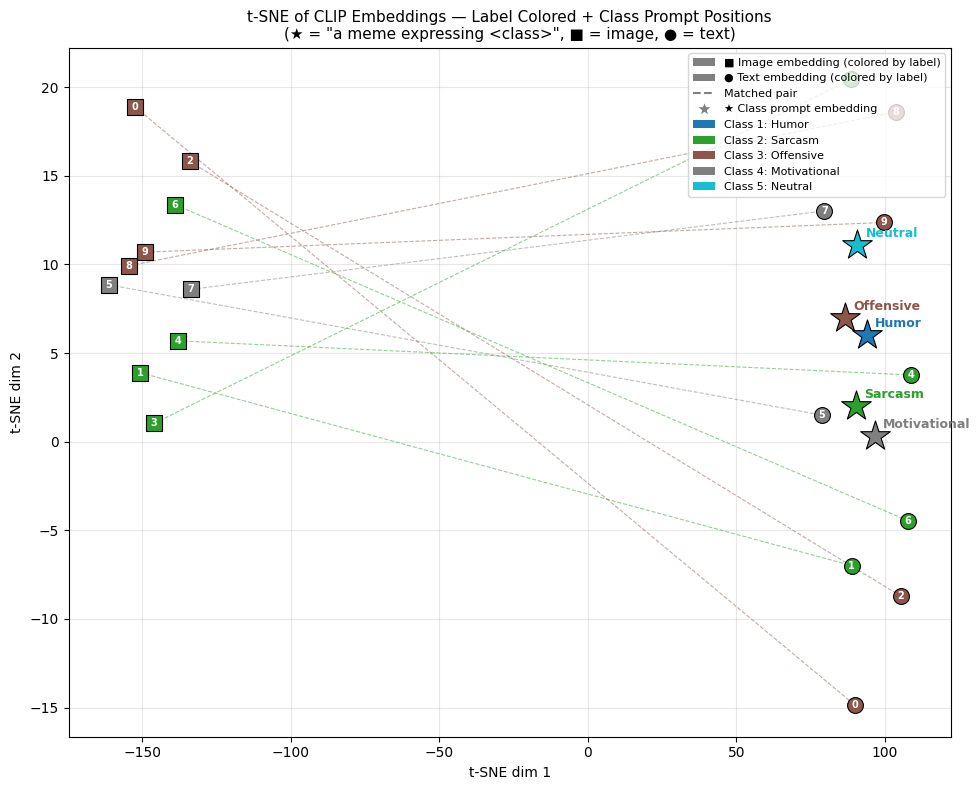

Saved: clip_tsne_enhanced.png

Nearest class prompt for each sample (cosine similarity):
Sample   True Label     Nearest Prompt    Sim
------------------------------------------------
0        Offensive      img→Humor      0.232
                        txt→Humor      0.723
1        Sarcasm        img→Motivational 0.255
                        txt→Humor      0.825
2        Offensive      img→Sarcasm    0.258
                        txt→Humor      0.870
3        Sarcasm        img→Sarcasm    0.259
                        txt→Humor      0.822
4        Sarcasm        img→Humor      0.270
                        txt→Humor      0.855
5        Motivational   img→Offensive  0.236
                        txt→Humor      0.828
6        Sarcasm        img→Motivational 0.263
                        txt→Humor      0.871
7        Motivational   img→Neutral    0.263
                        txt→Offensive  0.823
8        Offensive      img→Motivational 0.230
                        txt→Offensive  0.789


In [ ]:
# # ── Enhanced t-SNE: label coloring + class prompt embeddings ──────────────────
# # Intention classes (1-indexed in dataset, 0-indexed here)
# INTENTION_LABELS = [
#     'Humor',        # class 1
#     'Sarcasm',      # class 2
#     'Offensive',    # class 3
#     'Motivational', # class 4
#     'Neutral',      # class 5
# ]
# intention_prompts = [f'a meme expressing {lbl.lower()}' for lbl in INTENTION_LABELS]

# # Encode class prompts with CLIP
# prompt_tokens = clip.tokenize(intention_prompts, truncate=True).to(device)
# with torch.no_grad():
#     prompt_emb = clip_model.encode_text(prompt_tokens).float()  # (5, 512)
# prompt_emb = F.normalize(prompt_emb, dim=-1).cpu().numpy()

# # Stack: 10 image + 10 text + 5 class prompts = 25 points
# all_emb_ext = np.concatenate([img_emb, txt_emb, prompt_emb], axis=0)  # (25, 512)

# tsne2 = TSNE(n_components=2, perplexity=6, random_state=42, init='pca')
# emb_2d_ext = tsne2.fit_transform(all_emb_ext)  # (25, 2)

# img_2d_ext    = emb_2d_ext[:N]       # (10, 2)
# txt_2d_ext    = emb_2d_ext[N:2*N]    # (10, 2)
# prompt_2d_ext = emb_2d_ext[2*N:]     # (5, 2)

# # Color by intention label (0-4)
# label_colors = plt.cm.tab10(np.linspace(0, 1, 5))
# sample_labels = [s['intention_num'] - 1 for s in samples]  # 0-indexed

# fig, ax = plt.subplots(figsize=(10, 8))

# # ── Draw sample points colored by label ───────────────────────────────────────
# for i in range(N):
#     lc = label_colors[sample_labels[i]]
#     # Image: square
#     ax.scatter(img_2d_ext[i, 0], img_2d_ext[i, 1],
#                marker='s', s=130, color=lc, zorder=3,
#                edgecolors='black', linewidths=0.8)
#     # Text: circle
#     ax.scatter(txt_2d_ext[i, 0], txt_2d_ext[i, 1],
#                marker='o', s=130, color=lc, zorder=3,
#                edgecolors='black', linewidths=0.8)
#     # Connect matched pair
#     ax.plot([img_2d_ext[i, 0], txt_2d_ext[i, 0]],
#             [img_2d_ext[i, 1], txt_2d_ext[i, 1]],
#             color=lc, linewidth=0.8, linestyle='--', alpha=0.5, zorder=2)
#     ax.annotate(str(i), xy=(img_2d_ext[i, 0], img_2d_ext[i, 1]),
#                 fontsize=7, ha='center', va='center', color='white', fontweight='bold')
#     ax.annotate(str(i), xy=(txt_2d_ext[i, 0], txt_2d_ext[i, 1]),
#                 fontsize=7, ha='center', va='center', color='white', fontweight='bold')

# # ── Draw class prompt embeddings as large stars ────────────────────────────────
# for j, (label, pt) in enumerate(zip(INTENTION_LABELS, prompt_2d_ext)):
#     ax.scatter(pt[0], pt[1], marker='*', s=500,
#                color=label_colors[j], zorder=5,
#                edgecolors='black', linewidths=0.8)
#     ax.annotate(label, xy=(pt[0], pt[1]),
#                 xytext=(6, 6), textcoords='offset points',
#                 fontsize=9, fontweight='bold',
#                 color=label_colors[j])

# # ── Legend ────────────────────────────────────────────────────────────────────
# legend_elements = [
#     mpatches.Patch(facecolor='gray', label='■ Image embedding (colored by label)'),
#     mpatches.Patch(facecolor='gray', label='● Text embedding (colored by label)'),
#     plt.Line2D([0], [0], color='gray', linestyle='--', label='Matched pair'),
#     plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
#                markersize=12, label='★ Class prompt embedding'),
# ]
# # Add one entry per intention class
# for j, label in enumerate(INTENTION_LABELS):
#     legend_elements.append(
#         mpatches.Patch(facecolor=label_colors[j], label=f'Class {j+1}: {label}')
#     )
# ax.legend(handles=legend_elements, fontsize=8, loc='upper right', framealpha=0.8)

# ax.set_title(
#     't-SNE of CLIP Embeddings — Label Colored + Class Prompt Positions\n'
#     '(★ = "a meme expressing <class>", ■ = image, ● = text)',
#     fontsize=11
# )
# ax.set_xlabel('t-SNE dim 1')
# ax.set_ylabel('t-SNE dim 2')
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('clip_tsne_enhanced.png', dpi=150)
# plt.show()
# print('Saved: clip_tsne_enhanced.png')

# # ── Print nearest class prompt for each sample ────────────────────────────────
# print('\nNearest class prompt for each sample (cosine similarity):')
# print(f'{"Sample":<8} {"True Label":<14} {"Nearest Prompt":<14} {"Sim":>6}')
# print('-' * 48)
# for i in range(N):
#     # Compare image embedding to all class prompts
#     sims_img = img_emb[i] @ prompt_emb.T   # (5,)
#     sims_txt = txt_emb[i] @ prompt_emb.T   # (5,)
#     best_img = sims_img.argmax()
#     best_txt = sims_txt.argmax()
#     true_lbl = INTENTION_LABELS[sample_labels[i]]
#     print(f'{i:<8} {true_lbl:<14} img→{INTENTION_LABELS[best_img]:<10} {sims_img[best_img]:.3f}')
#     print(f'{"":<8} {"":<14} txt→{INTENTION_LABELS[best_txt]:<10} {sims_txt[best_txt]:.3f}')


这个图其实是不对的

## 6.3 CLIP Zero-Shot Classification (Intention & Sentiment)

Use CLIP's image encoder + text prompts to classify memes **without any training**.
For each test image, compute cosine similarity against all class prompts and take argmax.

This answers: *how much does CLIP already know about meme intention/sentiment?*  
It serves as a clean upper-bound reference — no learnable parameters involved.

**MET-Meme label definitions:**
- Intention (5 classes): Interactive, Expressive, Entertaining, Offensive, Other
- Sentiment (7 classes): Happiness, Love, Anger, Sorrow, Fear, Hate, Surprise

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

# ── Label definitions (MET-Meme) ──────────────────────────────────────────────
INTENTION_LABELS = [
    'Interactive',   # intention_num = 1
    'Expressive',    # intention_num = 2
    'Entertaining',  # intention_num = 3
    'Offensive',     # intention_num = 4
    'Other',         # intention_num = 5
]
SENTIMENT_LABELS = [
    'Happiness',  # sentiment_num = 1
    'Love',       # sentiment_num = 2
    'Anger',      # sentiment_num = 3
    'Sorrow',     # sentiment_num = 4
    'Fear',       # sentiment_num = 5
    'Hate',       # sentiment_num = 6
    'Surprise',   # sentiment_num = 7
]

# Prompt templates
intention_prompts = [f'a meme that is {lbl.lower()}' for lbl in INTENTION_LABELS]
sentiment_prompts = [f'a meme expressing {lbl.lower()}' for lbl in SENTIMENT_LABELS]

# ── Sample 40 memes from test set ─────────────────────────────────────────────
N_EVAL = 40
eval_samples = [hf['test'][i] for i in range(N_EVAL)]

eval_images = torch.stack([
    clip_preprocess(s['image'].convert('RGB')) for s in eval_samples
]).to(device)  # (40, 3, 224, 224)

true_intention = [s['intention_num'] - 1 for s in eval_samples]  # 0-indexed
true_sentiment = [s['sentiment_num'] - 1 for s in eval_samples]  # 0-indexed

# ── Encode prompts ────────────────────────────────────────────────────────────
with torch.no_grad():
    img_feats = clip_model.encode_image(eval_images).float()          # (40, 512)
    img_feats = F.normalize(img_feats, dim=-1)

    int_tokens  = clip.tokenize(intention_prompts, truncate=True).to(device)
    sent_tokens = clip.tokenize(sentiment_prompts, truncate=True).to(device)
    int_feats   = F.normalize(clip_model.encode_text(int_tokens).float(),  dim=-1)  # (5, 512)
    sent_feats  = F.normalize(clip_model.encode_text(sent_tokens).float(), dim=-1)  # (7, 512)

# ── Zero-shot prediction: argmax cosine similarity ────────────────────────────
int_sims  = (img_feats @ int_feats.T).cpu().numpy()   # (40, 5)
sent_sims = (img_feats @ sent_feats.T).cpu().numpy()  # (40, 7)

pred_intention = int_sims.argmax(axis=1)
pred_sentiment = sent_sims.argmax(axis=1)

# ── Metrics ───────────────────────────────────────────────────────────────────
int_acc    = accuracy_score(true_intention, pred_intention)
int_recall = recall_score(true_intention, pred_intention, average='macro', zero_division=0)
sent_acc    = accuracy_score(true_sentiment, pred_sentiment)
sent_recall = recall_score(true_sentiment, pred_sentiment, average='macro', zero_division=0)

print('=' * 52)
print(f'CLIP Zero-Shot — Intention ({N_EVAL} test samples)')
print('=' * 52)
print(f'  Accuracy        : {int_acc*100:.1f}%')
print(f'  Macro Recall    : {int_recall*100:.1f}%')
print(f'  Random baseline : {100/len(INTENTION_LABELS):.1f}%')
print()
print(classification_report(
    true_intention, pred_intention,
    target_names=INTENTION_LABELS, zero_division=0
))

print('=' * 52)
print(f'CLIP Zero-Shot — Sentiment ({N_EVAL} test samples)')
print('=' * 52)
print(f'  Accuracy        : {sent_acc*100:.1f}%')
print(f'  Macro Recall    : {sent_recall*100:.1f}%')
print(f'  Random baseline : {100/len(SENTIMENT_LABELS):.1f}%')
print()
print(classification_report(
    true_sentiment, pred_sentiment,
    target_names=SENTIMENT_LABELS, zero_division=0
))


## 6.4 CLIP Concat Baseline

Direct concatenation of raw CLIP embeddings → linear classifier, **no projection, no incongruity module**.

This is the ablation baseline for Section 7:  
- If concat(512+512)→Linear already performs well, the added complexity of Section 7 is not justified
- If Section 7 outperforms this, it shows the incongruity module adds value beyond raw alignment

In [31]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CONCAT_EPOCHS      = 10
CONCAT_LR          = 5e-4
CONCAT_WEIGHT_DECAY= 1e-3
CONCAT_BATCH_SIZE  = 64

# ── Paths ─────────────────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)
CONCAT_CKPT    = 'artifacts/clip_concat_best.pt'
CONCAT_HISTORY = 'artifacts/clip_concat_history.npy'
CONCAT_EMB     = 'artifacts/clip_concat_emb.npz'

# ── Model ─────────────────────────────────────────────────────────────────────
class CLIPConcatClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.head = nn.Linear(1024, num_classes)

    def forward(self, img_feat, txt_feat):
        return self.head(torch.cat([img_feat, txt_feat], dim=-1))


# ── Pre-cache CLIP embeddings (skip if already saved) ─────────────────────────
def cache_clip_embeddings(hf_split):
    all_img, all_txt, all_lbl = [], [], []
    loader = DataLoader(CLIPDataset(hf_split), batch_size=CONCAT_BATCH_SIZE, shuffle=False)
    clip_model.eval()
    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs, texts = imgs.to(device), texts.to(device)
            i_feat = F.normalize(clip_model.encode_image(imgs).float(), dim=-1).cpu()
            t_feat = F.normalize(clip_model.encode_text(texts).float(), dim=-1).cpu()
            all_img.append(i_feat); all_txt.append(t_feat); all_lbl.append(labels)
    return torch.cat(all_img), torch.cat(all_txt), torch.cat(all_lbl)

if os.path.exists(CONCAT_EMB):
    print('Loading cached CLIP embeddings...')
    data = np.load(CONCAT_EMB)
    tr_img = torch.from_numpy(data['tr_img']); tr_txt = torch.from_numpy(data['tr_txt']); tr_lbl = torch.from_numpy(data['tr_lbl'])
    va_img = torch.from_numpy(data['va_img']); va_txt = torch.from_numpy(data['va_txt']); va_lbl = torch.from_numpy(data['va_lbl'])
    te_img = torch.from_numpy(data['te_img']); te_txt = torch.from_numpy(data['te_txt']); te_lbl = torch.from_numpy(data['te_lbl'])
else:
    print('Caching CLIP embeddings for all splits...')
    tr_img, tr_txt, tr_lbl = cache_clip_embeddings(hf['train'])
    va_img, va_txt, va_lbl = cache_clip_embeddings(hf['validation'])
    te_img, te_txt, te_lbl = cache_clip_embeddings(hf['test'])
    np.savez(CONCAT_EMB,
             tr_img=tr_img.numpy(), tr_txt=tr_txt.numpy(), tr_lbl=tr_lbl.numpy(),
             va_img=va_img.numpy(), va_txt=va_txt.numpy(), va_lbl=va_lbl.numpy(),
             te_img=te_img.numpy(), te_txt=te_txt.numpy(), te_lbl=te_lbl.numpy())
    print(f'Saved to {CONCAT_EMB}')

from torch.utils.data import TensorDataset
tr_loader = DataLoader(TensorDataset(tr_img, tr_txt, tr_lbl), batch_size=CONCAT_BATCH_SIZE, shuffle=True)
va_loader = DataLoader(TensorDataset(va_img, va_txt, va_lbl), batch_size=CONCAT_BATCH_SIZE)
te_loader = DataLoader(TensorDataset(te_img, te_txt, te_lbl), batch_size=CONCAT_BATCH_SIZE)

# ── Train or load checkpoint ───────────────────────────────────────────────────
concat_model = CLIPConcatClassifier(num_classes=num_classes).to(device)

if os.path.exists(CONCAT_CKPT) and os.path.exists(CONCAT_HISTORY):
    print(f'Loading checkpoint from {CONCAT_CKPT}...')
    concat_model.load_state_dict(torch.load(CONCAT_CKPT, map_location=device))
    history = np.load(CONCAT_HISTORY, allow_pickle=True).item()
    print(f'Loaded. Best val acc: {max(history["val_acc"])*100:.2f}%')
else:
    optimizer = torch.optim.AdamW(concat_model.parameters(), lr=CONCAT_LR, weight_decay=CONCAT_WEIGHT_DECAY)
    history   = {'train_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(CONCAT_EPOCHS):
        concat_model.train()
        epoch_loss = 0.0
        for img_f, txt_f, lbl in tr_loader:
            img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
            optimizer.zero_grad()
            loss = nn.CrossEntropyLoss()(concat_model(img_f, txt_f), lbl)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history['train_loss'].append(epoch_loss / len(tr_loader))

        concat_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for img_f, txt_f, lbl in va_loader:
                img_f, txt_f, lbl = img_f.to(device), txt_f.to(device), lbl.long().to(device)
                correct += (concat_model(img_f, txt_f).argmax(1) == lbl).sum().item()
                total   += lbl.size(0)
        val_acc = correct / total
        history['val_acc'].append(val_acc)
        print(f'  Epoch {epoch+1:02d} — train loss: {history["train_loss"][-1]:.4f}  val acc: {val_acc:.4f}')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in concat_model.state_dict().items()}

    concat_model.load_state_dict(best_state)
    torch.save(best_state, CONCAT_CKPT)
    np.save(CONCAT_HISTORY, history)
    print(f'Saved checkpoint → {CONCAT_CKPT}')
    print(f'Saved history    → {CONCAT_HISTORY}')

# ── Test evaluation ───────────────────────────────────────────────────────────
concat_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for img_f, txt_f, lbl in te_loader:
        img_f, txt_f = img_f.to(device), txt_f.to(device)
        all_preds.append(concat_model(img_f, txt_f).argmax(1).cpu())
        all_true.append(lbl)
all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()

concat_acc    = accuracy_score(all_true, all_preds)
concat_recall = recall_score(all_true, all_preds, average='macro', zero_division=0)
print(f'\nCLIP Concat Baseline — Test Accuracy : {concat_acc*100:.2f}%')
print(f'CLIP Concat Baseline — Macro Recall  : {concat_recall*100:.2f}%')
print()
print(classification_report(all_true, all_preds, target_names=INTENTION_LABELS, zero_division=0))


Caching CLIP embeddings for all splits...


KeyboardInterrupt: 

## 7. CLIP-based Sentiment-Incongruity-Aware Fusion

The ResNet+BERT fusion failed because the two encoder spaces are completely unaligned —
fusion operates on meaningless vector combinations.

CLIP (ViT-B/32) jointly trains image and text encoders with a contrastive objective,
so their 512-dim outputs **live in the same semantic space** and are directly comparable.

We reuse `SentimentIncongruityFusion` unchanged, replacing only the encoders:
- `CLIPImageEncoder`: frozen ViT-B/32 image tower + trainable Linear(512→64)
- `CLIPTextEncoder`: frozen ViT-B/32 text tower + trainable Linear(512→64)

Everything else (fusion module, MLP head, training loop) stays identical for a fair comparison.

In [23]:
# ── CLIP Encoders ─────────────────────────────────────────────────────────────
# clip_model and clip_preprocess are already loaded from Section 6.

class CLIPImageEncoder(nn.Module):
    """Frozen CLIP ViT-B/32 image tower + trainable projection to output_dim."""
    def __init__(self, output_dim=64):
        super().__init__()
        self.clip = clip_model.visual
        for p in self.clip.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        # x: (batch, 3, 224, 224) preprocessed by clip_preprocess
        with torch.no_grad():
            feat = clip_model.encode_image(x).float()  # (batch, 512)
            feat = F.normalize(feat, dim=-1)
        return self.proj(feat)                          # (batch, output_dim)


class CLIPTextEncoder(nn.Module):
    """Frozen CLIP ViT-B/32 text tower + trainable projection to output_dim."""
    def __init__(self, output_dim=64):
        super().__init__()
        for p in clip_model.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        # x: (batch, 77) token ids from clip.tokenize
        with torch.no_grad():
            feat = clip_model.encode_text(x).float()   # (batch, 512)
            feat = F.normalize(feat, dim=-1)
        return self.proj(feat)                          # (batch, output_dim)


print('CLIPImageEncoder and CLIPTextEncoder defined.')

CLIPImageEncoder and CLIPTextEncoder defined.


In [24]:
# ── CLIP Dataset ──────────────────────────────────────────────────────────────
# CLIP requires its own preprocessing (clip_preprocess) and tokenization.

class CLIPDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = clip_preprocess(row['image'].convert('RGB'))  # (3, 224, 224)
        # clip.tokenize returns (1, 77); squeeze to (77,)
        text  = clip.tokenize([row['caption']], truncate=True).squeeze(0)  # (77,)
        label = row['intention_num'] - 1
        return image, text, label


clip_trainset = CLIPDataset(hf['train'])
clip_valset   = CLIPDataset(hf['validation'])
clip_testset  = CLIPDataset(hf['test'])

clip_traindata = DataLoader(clip_trainset, batch_size=64, shuffle=True)
clip_valdata   = DataLoader(clip_valset,   batch_size=64)
clip_testdata  = DataLoader(clip_testset,  batch_size=64)

print(f'CLIP datasets ready — Train: {len(clip_trainset)}, Val: {len(clip_valset)}, Test: {len(clip_testset)}')

CLIP datasets ready — Train: 2711, Val: 338, Test: 340


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
CLIP_INCONG_EPOCHS       = 10
CLIP_INCONG_LR           = 5e-4
CLIP_INCONG_WEIGHT_DECAY = 1e-3

# ── Paths ─────────────────────────────────────────────────────────────────────
CLIP_INCONG_CKPT = 'artifacts/clip_incong_fusion.pt'

# ── Train or load ─────────────────────────────────────────────────────────────
if os.path.exists(CLIP_INCONG_CKPT):
    print(f'Checkpoint found. Loading from {CLIP_INCONG_CKPT}...')
    clip_incong_model = torch.load(CLIP_INCONG_CKPT, map_location=device).to(device)
    print('Loaded. Skipping training.')
else:
    clip_fusion   = SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes)
    clip_head     = MLP(69, 256, num_classes)
    clip_encoders = [CLIPImageEncoder(output_dim=64), CLIPTextEncoder(output_dim=64)]

    print('Training CLIP-based Sentiment-Incongruity-Aware Fusion...')
    train(
        clip_encoders, clip_fusion, clip_head,
        clip_traindata, clip_valdata,
        total_epochs=CLIP_INCONG_EPOCHS,
        task='classification',
        optimtype=torch.optim.AdamW,
        is_packed=False,
        lr=CLIP_INCONG_LR,
        save=CLIP_INCONG_CKPT,
        weight_decay=CLIP_INCONG_WEIGHT_DECAY,
        objective=torch.nn.CrossEntropyLoss(),
        input_to_float=False
    )
    clip_incong_model = torch.load(CLIP_INCONG_CKPT, map_location=device).to(device)

print('\n--- CLIP Fusion Test Results ---')
test(
    clip_incong_model, clip_testdata,
    is_packed=False,
    task='classification',
    criterion=torch.nn.CrossEntropyLoss(),
    no_robust=True
)


NameError: name 'SentimentIncongruityFusion' is not defined

In [ ]:
# ── Evaluate CLIP Fusion ──────────────────────────────────────────────────────
clip_incong_model.eval()
correct_clip, total_clip = 0, 0
with torch.no_grad():
    for imgs, text, label in clip_testdata:
        imgs  = imgs.to(device)
        text  = text.to(device)
        label = label.long().to(device)
        out   = clip_incong_model([imgs, text])
        correct_clip += (out.argmax(1) == label).sum().item()
        total_clip   += label.size(0)

clip_test_acc = 100 * correct_clip / total_clip
print(f'CLIP Fusion Test Accuracy: {clip_test_acc:.2f}%')

clip_full = MMDL(
    [CLIPImageEncoder(output_dim=64), CLIPTextEncoder(output_dim=64)],
    SentimentIncongruityFusion(input_dim=64, num_sentiments=num_classes),
    MLP(69, 256, num_classes)
)
print(f'CLIP Fusion trainable parameters: {count_params(clip_full):,}')

In [ ]:
# ── Full Comparison Chart ─────────────────────────────────────────────────────
all_results_clip = {
    **unimodal_results,                            # Unimodal-Image, Unimodal-Text
    'Incong\n(ResNet+BERT)': 100 * correct / total,  # from Section 5
    'Incong\n(CLIP)': clip_test_acc,
}

names  = list(all_results_clip.keys())
accs   = [all_results_clip[n] for n in names]
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Unimodal vs Incongruity Fusion\n(ResNet+BERT unaligned vs CLIP aligned)')
ax.set_ylim(0, max(accs) + 10)
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (5-class)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('clip_vs_resnet_fusion.png', dpi=150)
plt.show()
print('Saved: clip_vs_resnet_fusion.png')

# Print delta
delta = clip_test_acc - (100 * correct / total)
print(f'\nCLIP fusion vs ResNet+BERT fusion: {delta:+.2f}% (positive = CLIP better)')